> **Model run note:** This version was last run on **29/06/2026** with **TUFLOW FV build 2025.2.1**.
>
> - **Control file used to run the model:** `.../Complete_Model/TUFLOWFV/runs/HYD_aed.fvc`
> - **Run log file (more information):** `.../Complete_Model/TUFLOWFV/runs/log/HYD_aed.log`

# Tutorial: Running TUFLOW FV with the AED Water-Quality Module

This notebook extends the official **BMT TFV tutorial** ([tfv.readthedocs.io](https://tfv.readthedocs.io/en/latest/examples/index.html)) by enabling the **AED (Aquatic EcoDynamics)** water-quality module on top of the standard TUFLOW FV estuary test case. The hydrodynamic model uses the **default configuration**; AED runs with **standard settings**. The aim is a minimal, end-to-end workflow to confirm the coupled hydro–WQ model is configured correctly and to visualise the outputs.

**This notebook covers**

1. Loading TUFLOW FV + AED NetCDF results (`HYD_aed.nc`).
2. Verifying the model ran by inspecting the mesh and a depth-averaged WQ snapshot (dissolved oxygen).
3. Diagnostic plots for **water-quality state variables** — Oxygen, TN, GPP, TSS, TP, TCHLA, Turbidity, PAR, Light — alongside velocity and density.
4. Use this as a **starting point** to customise TUFLOW FV + AED runs for your own estuarine application.

> **Source files referenced:** `HYD_aed.nc` (results) and `polyline.csv` (curtain transect).

---

## What you will learn

1. **Load** a TUFLOW FV NetCDF result file as an xarray Dataset.
2. **Map snapshots** - depth-averaged surface plots (example: dissolved oxygen).
3. **Surface vs. seabed vs. depth-averaged** - 3×3 grid contrasting Velocity, TSS and TP.
4. **Timeseries** - extract WQ state variables (`WQ_PHY_MIXED`, `WQ_DIAG_TOT_TSS`, `WQ_DIAG_PHY_TCHLA`) at named stations.
5. **Sheets & statistics** - depth-averaged GPP sheets and 99th-percentile maps over a time window.
6. **Curtains** - vertical slices of WQ fields along a user-defined polyline transect.
7. **Profile + timeseries** - vertical TSS structure at one station, plus its depth-averaged history.
8. **Hovmoller** - depth vs. time diagrams of TSS and Turbidity at a station.
9. **Animations** - export an MP4 of the evolving Turbidity field.
10. **Interactive views** - Jupyter-widget plot with a time slider.

## Requirements

```bash
pip install tfv xarray matplotlib seaborn netCDF4 ipympl
# For MP4 export:
sudo apt install ffmpeg
```

## How to use

1. Open in **JupyterLab** or **VS Code** with the Jupyter extension.
2. Update the `model_folder` path in Section 1 to point at your local results directory.
3. Run **Run All** the first time, then experiment by swapping the WQ variable, station, time, or colour ranges in each cell.

> **Note for GitHub viewers:** Outputs are committed with the notebook so the rendered figures display on GitHub. Re-run after pulling to refresh against new model results.

## 1. Load the model results

We open the NetCDF file directly with `xarray`. The `decode_times=False` flag is important because TUFLOW FV writes time in a non-CF convention — the `tfv` accessor decodes it on the next step. The displayed `Dataset` lists all available state variables (hydrodynamic + AED water-quality) and their dimensions.

In [ ]:
import xarray as xr  # We utilise xarray to do all the heavy lifting 
import tfv.xarray
from pathlib import Path 
model_folder = Path(r'/media/fileshare/AED/MATT/SpoonTest/spoon_tfvaed_example/TUFLOWFV/outputs/./media/fileshare/AED/MATT/SpoonTest/spoon_tfvaed_example/TUFLOWFV/outputs/results/')
model_file = 'HYD_aed.nc'

ds = xr.open_dataset(model_folder / model_file, decode_times=False)
ds

getfattr: /media/fileshare/AED/RONY/15_TUFLOWFV_aed/15_TUFLOWFV/Tutorial_Module_05_Estuary_Module/Tutorial_Module_05_Estuary_Module/Complete_Model/TUFLOWFV/results/HYD_aed.nc: Operation not supported


<xarray.Dataset> Size: 452MB
Dimensions:                    (Time: 145, NumCells2D: 1375, MaxNumCellVert: 4,
                                NumCells3D: 6453, NumVert2D: 1419,
                                NumLayerFaces3D: 7828)
Dimensions without coordinates: Time, NumCells2D, MaxNumCellVert, NumCells3D,
                                NumVert2D, NumLayerFaces3D
Data variables: (12/139)
    ResTime                    (Time) float64 1kB ...
    cell_Nvert                 (NumCells2D) int32 6kB ...
    cell_node                  (NumCells2D, MaxNumCellVert) int32 22kB ...
    NL                         (NumCells2D) int32 6kB ...
    idx2                       (NumCells3D) int32 26kB ...
    idx3                       (NumCells2D) int32 6kB ...
    ...                         ...
    WQ_DIAG_TOT_PAR            (Time, NumCells3D) float32 4MB ...
    WQ_DIAG_TOT_UV             (Time, NumCells3D) float32 4MB ...
    WQ_DIAG_TOT_EXTC           (Time, NumCells3D) float32 4MB ...
    WQ_DIAG_TRC_TR1_VVEL       (Time, NumCells3D) float32 4MB ...
    WQ_DIAG_TRC_TR2_VVEL       (Time, NumCells3D) float32 4MB ...
    WQ_DIAG_TRC_TR3_VVEL       (Time, NumCells3D) float32 4MB ...
Attributes:
    Origin:     Created by TUFLOWFV
    Type:       Cell-centred TUFLOWFV output
    spherical:  true
    Dry depth:  0.01

### Attach the `tfv` accessor

Calling `ds.tfv` (or wrapping the dataset in `tfv.xarray.TfvDomain`) decodes the model grid, time axis, and 3D layer faces. The returned `TfvDomain` is what we use for every plot below.

In [2]:
# These are equivalent - use whichever you prefer.
fv = ds.tfv
# fv = tfv.xarray.TfvDomain(ds)
fv 

<xarray.Dataset> Size: 452MB
Dimensions:                    (Time: 145, NumLayerFaces3D: 7828,
                                NumCells2D: 1375, NumCells3D: 6453)
Coordinates:
  * Time                       (Time) datetime64[us] 1kB 2011-05-01 ... 2011-...
Dimensions without coordinates: NumLayerFaces3D, NumCells2D, NumCells3D
Data variables: (12/127)
    ResTime                    (Time) float64 1kB 1.87e+05 ... 1.871e+05
    layerface_Z                (Time, NumLayerFaces3D) float32 5MB ...
    stat                       (Time, NumCells2D) int32 798kB ...
    H                          (Time, NumCells2D) float32 798kB ...
    V_x                        (Time, NumCells3D) float32 4MB ...
    V_y                        (Time, NumCells3D) float32 4MB ...
    ...                         ...
    WQ_DIAG_TOT_PAR            (Time, NumCells3D) float32 4MB ...
    WQ_DIAG_TOT_UV             (Time, NumCells3D) float32 4MB ...
    WQ_DIAG_TOT_EXTC           (Time, NumCells3D) float32 4MB ...
    WQ_DIAG_TRC_TR1_VVEL       (Time, NumCells3D) float32 4MB ...
    WQ_DIAG_TRC_TR2_VVEL       (Time, NumCells3D) float32 4MB ...
    WQ_DIAG_TRC_TR3_VVEL       (Time, NumCells3D) float32 4MB ...
Attributes:
    Origin:     Created by TUFLOWFV
    Type:       Cell-centred TUFLOWFV output
    spherical:  true
    Dry depth:  0.01

TUFLOW FV domain xarray accessor object

## 2. Quick map snapshots

`fv.plot()` with no arguments renders the model mesh, which is a good sanity check that the grid loaded correctly. With a variable name + time it plots a depth-averaged horizontal map — below we use **dissolved oxygen** (`WQ_OXY_OXY`) at the model surface as a first WQ snapshot.

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


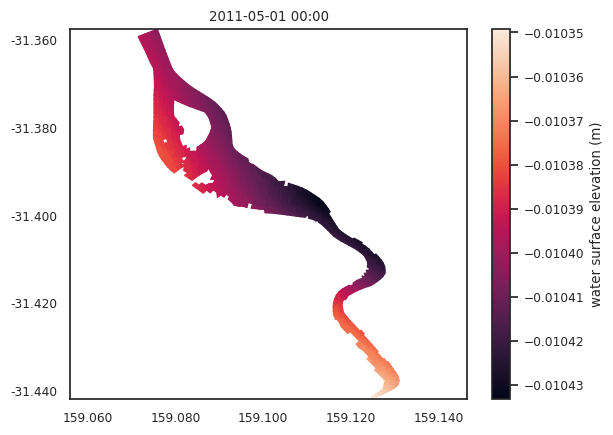

In [38]:
fv.plot()

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


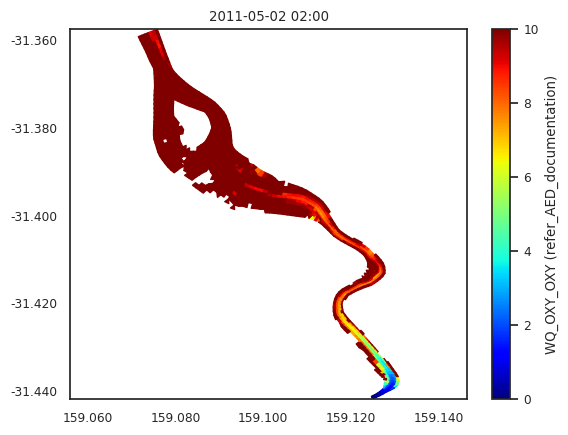

In [37]:
fv.plot('WQ_OXY_OXY', '2011-05-02 02:00', cmap='jet', clim=(0, 10), datum='depth')


### Three-panel side-by-side view

A common pattern is to compare three related variables at the same time. Here we show **Oxygen** (with velocity vectors overlaid), **Total Nitrogen**, and **Gross Primary Production (GPP)**. We use `datum='depth'` with `limits=(0, 1)` to render the **surface 1 m** (try `datum='height'` to flip to the bottom 1 m). `plot_vector` overlays velocity arrows on top of the oxygen field.

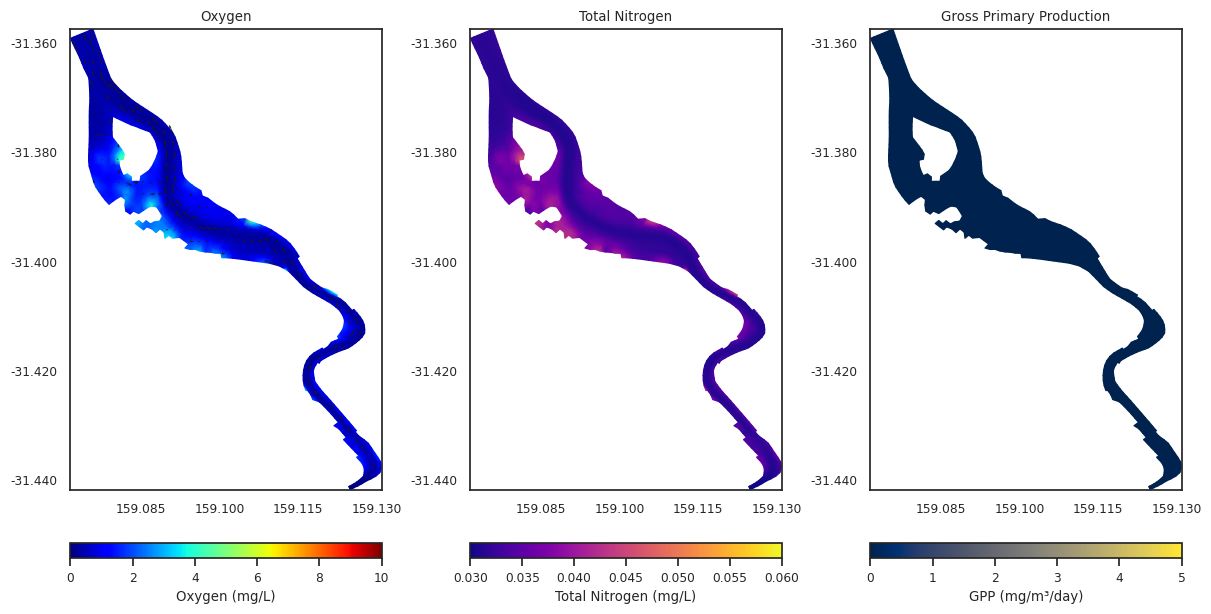

In [46]:
import matplotlib.pyplot as plt

# With datum='depth', this is the surface 1m. 
# Experiment with datum='height' to see how the results change. 
datum = 'depth'
limits = (0,1)

fig, axes = plt.subplots(ncols=3, figsize=(12, 6), constrained_layout=True)

ts = '2011-05-01 02:00'

ax = axes[0]
p1 = fv.plot('WQ_OXY_OXY', ts, ax=ax,  shading='interp', cmap='jet', clim=(0, 10), datum=datum, limits=limits, colorbar=False)  # By setting datum to depth, this is now the "surface 1m")
v1 = fv.plot_vector('V', ts, ax=ax, color='k')   # We can plot a vector overlay using the `plot_vector` method here
ax.set_title('Oxygen')
plt.colorbar(p1.patch, ax=ax, orientation='horizontal', label='Oxygen (mg/L)')

ax = axes[1]
p2 = fv.plot('WQ_DIAG_TOT_TN', ts, ax=ax,  shading='interp', cmap='plasma', clim=(0.03, 0.06), datum=datum, limits=limits, colorbar=False)
ax.set_title('Total Nitrogen')
plt.colorbar(p2.patch, ax=ax, orientation='horizontal', label='Total Nitrogen (mg/L)')

ax = axes[2]
p3 = fv.plot('WQ_DIAG_PHY_GPP', ts, ax=ax, shading='interp', cmap='cividis', clim=(0, 5), datum=datum, limits=limits, colorbar=False)
ax.set_title('Gross Primary Production')
plt.colorbar(p3.patch, ax=ax, orientation='horizontal', label='GPP (mg/m³/day)')

plt.show()

## 3. Surface vs. seabed vs. depth-averaged

A 3×3 grid contrasting three variables at three depth treatments:

- **Columns** - Velocity (`V`), Total Suspended Solids (`WQ_DIAG_TOT_TSS`), Total Phosphorus (`WQ_DIAG_TOT_TP`).
- **Top row** - surface 1 m (`datum='depth'`, `limits=(0, 1)`).
- **Middle row** - near-seabed 1 m (`datum='height'`, `limits=(0, 1)`).
- **Bottom row** - depth-averaged (default).

This is a quick **stratification-vs-mixing diagnostic for water-quality fields** — vertical differences in any column reveal whether TSS/TP are uniformly mixed or settling/accumulating at depth.

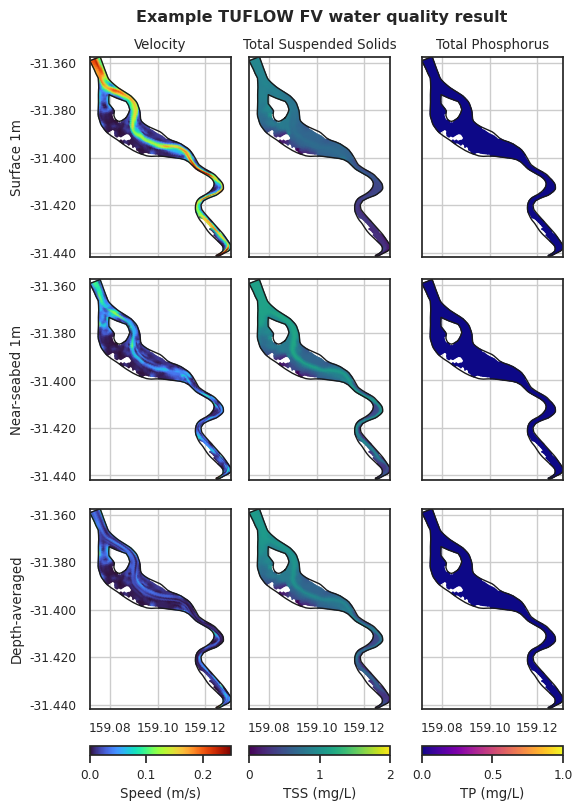

In [52]:
import matplotlib.ticker as mticker
vel_spec = dict(cmap='turbo', clim=(0, 0.25), shading='interp', colorbar=False, boundary=True)
tss_spec = dict(cmap='viridis', clim=(0, 2), shading='interp', colorbar=False, boundary=True)
tp_spec = dict(cmap='plasma', clim=(0, 1), shading='interp', colorbar=False, boundary=True)

titles = {0: 'Velocity', 1: 'Total Suspended Solids', 2: 'Total Phosphorus'}
ylabels = {0: 'Surface 1m', 1: 'Near-seabed 1m', 2: 'Depth-averaged'}

time = '2011-05-03 18:00'

sns.set_theme(style='white', font_scale=0.8)

fig, axes = plt.subplots(ncols=3, nrows=3, figsize=(5.75, 8), constrained_layout=True)

# Top row - "surface" 1m.
# We assign these to a variable (c1, c2, c3) for our colorbar later.
c1 = fv.plot('V', time, ax=axes[0][0], datum='depth', **vel_spec)
c2 = fv.plot('WQ_DIAG_TOT_TSS', time, ax=axes[0][1], datum='depth', **tss_spec)
c3 = fv.plot('WQ_DIAG_TOT_TP', time, ax=axes[0][2], datum='depth', **tp_spec)

# Middle row - "bottom" 1m.
fv.plot('V', time, ax=axes[1][0], datum='height', **vel_spec)
fv.plot('WQ_DIAG_TOT_TSS', time, ax=axes[1][1], datum='height', **tss_spec)
fv.plot('WQ_DIAG_TOT_TP', time, ax=axes[1][2], datum='height', **tp_spec)

# Bottom row - Depth averaged
fv.plot('V', time, ax=axes[2][0], **vel_spec)
fv.plot('WQ_DIAG_TOT_TSS', time, ax=axes[2][1], **tss_spec)
fv.plot('WQ_DIAG_TOT_TP', time, ax=axes[2][2], **tp_spec)

# Colorbars
plt.colorbar(c1.patch, ax=axes[2][0], orientation='horizontal', label='Speed (m/s)', aspect=15)
plt.colorbar(c2.patch, ax=axes[2][1], orientation='horizontal', label='TSS (mg/L)', aspect=15)
plt.colorbar(c3.patch, ax=axes[2][2], orientation='horizontal', label='TP (mg/L)', aspect=15)

# Figure cleanup
for i in range(3): # Cols
    for j in range(3): # Rows
        ax = axes[j][i]
        
        # Common settings
        ax.set_aspect('equal')
        ax.grid(True)

        # Our xticks are too cramped - this will limit the max ticks to 3
        ax.xaxis.set_major_locator(mticker.MaxNLocator(3))
        ticks_loc = ax.get_xticks().tolist()
        ax.xaxis.set_major_locator(mticker.FixedLocator(ticks_loc))
        ax.set_xticklabels([f'{x:0.2f}' for x in ticks_loc])

        # Set titles based on our dictionary
        if j == 0:
            ax.set_title(titles[i])
        else:
            ax.set_title('')

        # Set ylabels based on our dictionary
        if i == 0:
            ax.set_ylabel(ylabels[j])

        # Turn off internal xticks
        if j != 2:
            ax.set_xticklabels([])

        # Turn off internal yticks
        if i != 0:
            ax.set_yticklabels([])

fig.suptitle('Example TUFLOW FV water quality result', fontweight='bold', x=0.55)

plt.show()

## 4. Point timeseries extraction

`fv.get_timeseries()` interpolates the chosen variables to one or more (x, y) stations across the full simulation time. Here we extract three WQ state variables — phytoplankton biomass (`WQ_PHY_MIXED`), total suspended solids (`WQ_DIAG_TOT_TSS`), and chlorophyll-a (`WQ_DIAG_PHY_TCHLA`) — at stations `P1` and `P2`. The result is an `xarray.Dataset` indexed by `(Time, Location)` — easy to convert to a pandas DataFrame for tabular plotting or CSV export.

In [104]:
locs = {
    'P1': (159.1, -31.39), 
    'P2': (159.115, -31.395), 
}

ts = fv.get_timeseries(['WQ_PHY_MIXED', 'WQ_DIAG_TOT_TSS', 'WQ_DIAG_PHY_TCHLA'], locs)
ts_df = ts.to_dataframe()

Extracting timeseries, please wait:   0%|          | 0/145 [00:00<?, ?it/s]

Extracting timeseries, please wait: 100%|██████████| 145/145 [00:04<00:00, 35.74it/s]


In [105]:
ts

<xarray.Dataset> Size: 8kB
Dimensions:            (Time: 145, Location: 2)
Coordinates:
  * Time               (Time) datetime64[us] 1kB 2011-05-01 ... 2011-05-07
  * Location           (Location) <U2 16B 'P1' 'P2'
    x                  (Location) float64 16B 159.1 159.1
    y                  (Location) float64 16B -31.39 -31.39
    z                  (Location) float32 8B -1.068 -4.886
Data variables:
    WQ_PHY_MIXED       (Time, Location) float64 2kB 0.0 0.0 0.2 ... 0.2 0.2 0.2
    WQ_DIAG_TOT_TSS    (Time, Location) float64 2kB 0.004 0.004 ... 0.9622
    WQ_DIAG_PHY_TCHLA  (Time, Location) float64 2kB 0.048 0.048 ... 0.048 0.048
Attributes:
    Origin:     Timeseries extracted from TUFLOWFV cell-centered output using...
    Type:       Timeseries cell from TUFLOWFV Output
    spherical:  true
    Dry depth:  0.01
    Datum:      sigma
    Limits:     (0, 1)
    Agg Fn:     mean

A quick sanity-check plot — TSS timeseries at station P2 using xarray's native plotting.

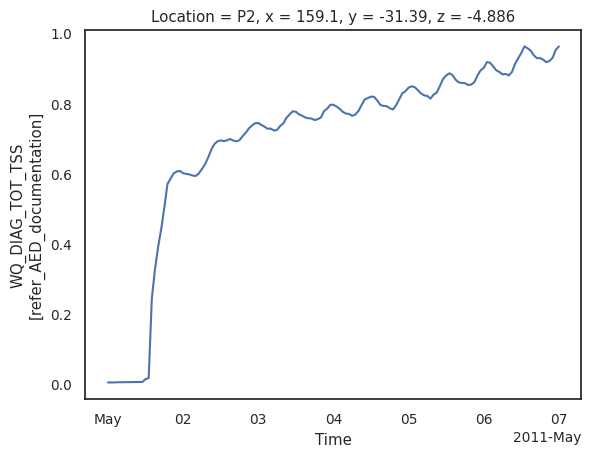

In [107]:
ts['WQ_DIAG_TOT_TSS'][:, 1].plot()

## 5. Sheets and statistics

A **sheet** is the depth-averaged (or depth-limited) horizontal slab of a variable, returned as a 2-D field per timestep — handy for animation frames or aggregation. Here we build a GPP (`WQ_DIAG_PHY_GPP`) sheet for the first two model days.

**Statistics** (`min`, `mean`, `max`, percentiles like `p99`) collapse the time axis to produce a single map showing extreme-value behaviour — useful for identifying productivity hotspots or stress events. Below we run them on near-seabed GPP and plot the 99th-percentile field.

In [108]:
sht = fv.get_sheet('WQ_DIAG_PHY_GPP', slice('2011-05-02', '2011-05-04'), datum='depth', limits=(0,2))
sht

<xarray.Dataset> Size: 3MB
Dimensions:          (Time: 72, NumLayerFaces3D: 7828, NumCells2D: 1375)
Coordinates:
  * Time             (Time) datetime64[us] 576B 2011-05-02 ... 2011-05-04T23:...
Dimensions without coordinates: NumLayerFaces3D, NumCells2D
Data variables:
    ResTime          (Time) float64 576B 1.87e+05 1.87e+05 ... 1.871e+05
    layerface_Z      (Time, NumLayerFaces3D) float32 2MB ...
    stat             (Time, NumCells2D) int32 396kB ...
    WQ_DIAG_PHY_GPP  (Time, NumCells2D) float64 792kB 0.0 0.0 0.0 ... 0.0 0.0
Attributes:
    Origin:     Created by TUFLOWFV
    Type:       Cell-centred TUFLOWFV output
    spherical:  true
    Dry depth:  0.01

TUFLOW FV domain xarray accessor object

In [109]:
stats = ['p5', 'p50', 'p97.5', 'p99', 'min', 'mean', 'max']

# Do stats on velocity for the bottom 1m (default of limits is (0, 1), and with datum='height', we get the bottom 1m). 
stat = fv.get_statistics(stats, 'WQ_DIAG_PHY_GPP', datum='height')
stat

...extracting sheet data: 100%|██████████| 145/145 [00:01<00:00, 111.77it/s]


<xarray.Dataset> Size: 114kB
Dimensions:                (Time: 1, NumLayerFaces3D: 7828, NumCells2D: 1375)
Coordinates:
  * Time                   (Time) datetime64[us] 8B 2011-05-01
Dimensions without coordinates: NumLayerFaces3D, NumCells2D
Data variables:
    ResTime                (Time) float64 8B 1.87e+05
    layerface_Z            (Time, NumLayerFaces3D) float32 31kB ...
    stat                   (Time, NumCells2D) int32 6kB ...
    WQ_DIAG_PHY_GPP_min    (Time, NumCells2D) float64 11kB 0.0 0.0 ... 0.0 0.0
    WQ_DIAG_PHY_GPP_mean   (Time, NumCells2D) float64 11kB 0.0 0.0 ... 0.0 0.0
    WQ_DIAG_PHY_GPP_max    (Time, NumCells2D) float64 11kB 0.0 0.0 ... 0.0 0.0
    WQ_DIAG_PHY_GPP_p5     (Time, NumCells2D) float64 11kB 0.0 0.0 ... 0.0 0.0
    WQ_DIAG_PHY_GPP_p50    (Time, NumCells2D) float64 11kB 0.0 0.0 ... 0.0 0.0
    WQ_DIAG_PHY_GPP_p97.5  (Time, NumCells2D) float64 11kB 0.0 0.0 ... 0.0 0.0
    WQ_DIAG_PHY_GPP_p99    (Time, NumCells2D) float64 11kB 0.0 0.0 ... 0.0 0.0
Attributes:
    Origin:     Created by TUFLOWFV
    Type:       Cell-centred TUFLOWFV output
    spherical:  true
    Dry depth:  0.01

TUFLOW FV domain xarray accessor object

Text(0.5, 1.0, 'Our 99th Percentile GPP Result')

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


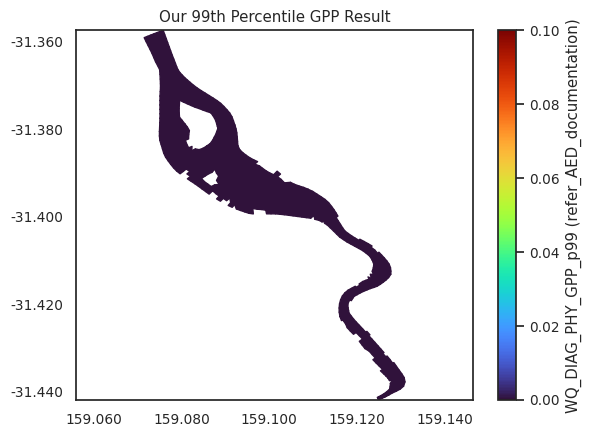

In [110]:
stat.plot('WQ_DIAG_PHY_GPP_p99', cmap='turbo', clim=(0,0.1))
plt.title('Our 99th Percentile GPP Result')

## 6. Curtain plots (vertical slices)

A **curtain** is a vertical cross-section along an arbitrary polyline (loaded here from `polyline.csv` — two columns of `x, y` coordinates). It exposes the stratification structure that map views collapse away. The seaborn theme below also normalises font sizes for publication-quality figures.

In [111]:
from matplotlib.gridspec import GridSpec
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns 
sns.set_theme(style='white', font_scale=0.9)

polyline = np.loadtxt('/media/fileshare/AED/MATT/SpoonTest/spoon_tfvaed_example/TUFLOWFV/outputs/polyline.csv', skiprows=1, delimiter=',')

### Map + curtain side-by-side

Pairing the depth-averaged map (left, narrow) with the curtain (right, wide) makes it obvious *where* the water-quality structure you're seeing happens. The black dashed line on the map is the polyline used for the curtain. Below we use **dissolved oxygen** (`WQ_OXY_OXY`) to spot any near-bed hypoxic pockets along the transect.

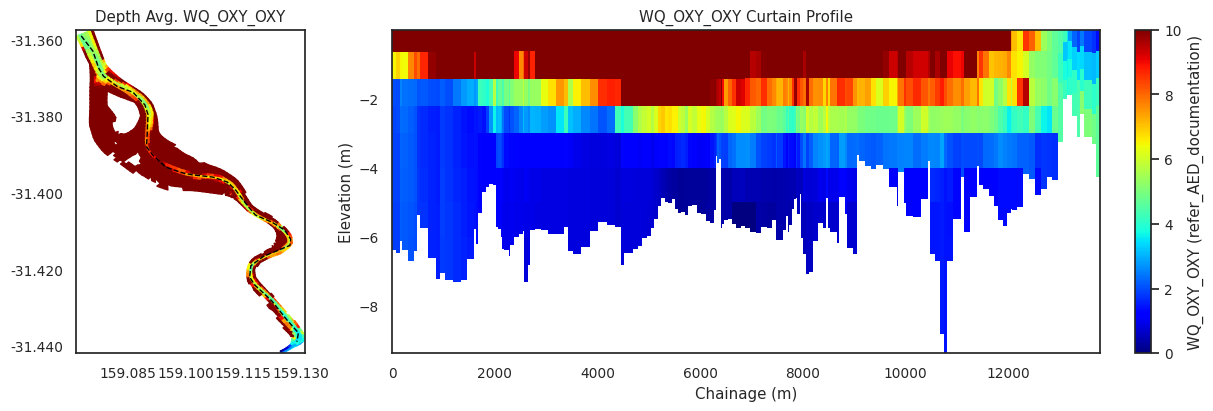

In [112]:
time = '2011-05-02 12:00'
vardict = {
     'WQ_OXY_OXY': dict(cmap='jet', clim=(0, 10)),
    }
var = 'WQ_OXY_OXY'

# Create figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={'width_ratios': [1, 3]}, constrained_layout=True)

cspec = vardict[var]
fv.plot(var, time, ax=ax1, colorbar=False, **cspec)
ax1.plot(polyline[:, 0], polyline[:, 1], lw=1, color='black', ls='--')
ax1.set_aspect('equal')
ax1.set_title(f'Depth Avg. {var}')

fv.plot_curtain(polyline, var, time, ax=ax2, ec='none', **cspec)
ax2.set_title(f'{var} Curtain Profile')

plt.show()

## 7. Profile and timeseries at a station

For a deeper look at one location we combine:

- a **vertical profile** (`fv.get_profile`) — TSS vs. depth at a single time, with model layer faces marked on the y-axis to show vertical resolution.
- a **depth-averaged timeseries** at the same station, providing temporal context.

Below we extend the location dictionary to a chain of stations along the estuary (`P1` … `P8`) so the same workflow can be reused at any point. The variable shown is `WQ_DIAG_TOT_TSS` — swap `var` to any other WQ field for a similar diagnostic.

In [113]:
# Extract the timeseries and profile data
loc = 'P2'
time = '2011-05-02 12:00'
var = 'WQ_DIAG_TOT_TSS'

locs = {
    'P1' : (159.0758, -31.3638),
    'P2' : (159.0845,  -31.3727),
    'P3' : (159.0906,  -31.3814),
    'P4' : (159.1001,  -31.3948),
    'P5' : (159.1154,  -31.4032),
    'P6' : (159.1266,  -31.4105),
    'P7' : (159.1202,  -31.4165),
    'P8' : (159.1178,  -31.4236),
}
ts = fv.get_timeseries(['WQ_DIAG_TOT_TSS'],locs)
prof = fv.get_profile(locs[loc],variables=['WQ_DIAG_TOT_TSS'])

Extracting timeseries, please wait:   0%|          | 0/145 [00:00<?, ?it/s]

Extracting timeseries, please wait: 100%|██████████| 145/145 [00:01<00:00, 104.13it/s]


Text(0.45, 0.98, 'TSS Profile and Timeseries')

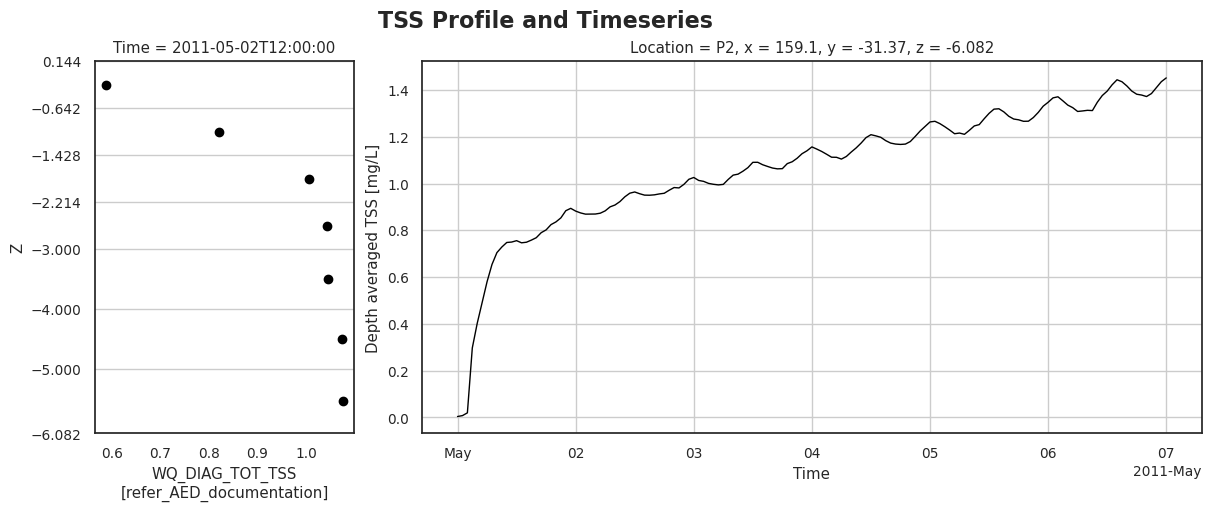

In [114]:
fig, ((ax1, ax2)) = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={'width_ratios': [1, 3]}, constrained_layout=True)
#  Plot profile
prof.sel(Time=time).plot.scatter(x='WQ_DIAG_TOT_TSS',y='Z', ax=ax1, color='black', lw=1)
zfaces = prof['layerface_Z'].sel(Time=time)
ax1.set_yticks(zfaces)
ax1.grid(axis='y')

# Plot timeseries
ts[var].sel(Location=loc).plot(ax=ax2, color='black', lw=1)
ax2.grid()
ax2.set_ylabel('Depth averaged TSS [mg/L]')

fig.suptitle('TSS Profile and Timeseries', fontweight='bold', x=0.45, fontsize=16)

### Multi-variable curtain stack — light, mixing and density

Stack curtains for variables that together describe the **light–mixing–density** environment driving primary production:

- `RHOW` — water density (top-down stratification).
- `WQ_DIAG_TOT_PAR` — photosynthetically active radiation.
- `WQ_PHY_MIXED` — mixed-phytoplankton biomass.
- `WQ_DIAG_TOT_LIGHT` — total light climate (depth-integrated).

Useful for visualising why phytoplankton biomass accumulates in some parts of the water column and not others.

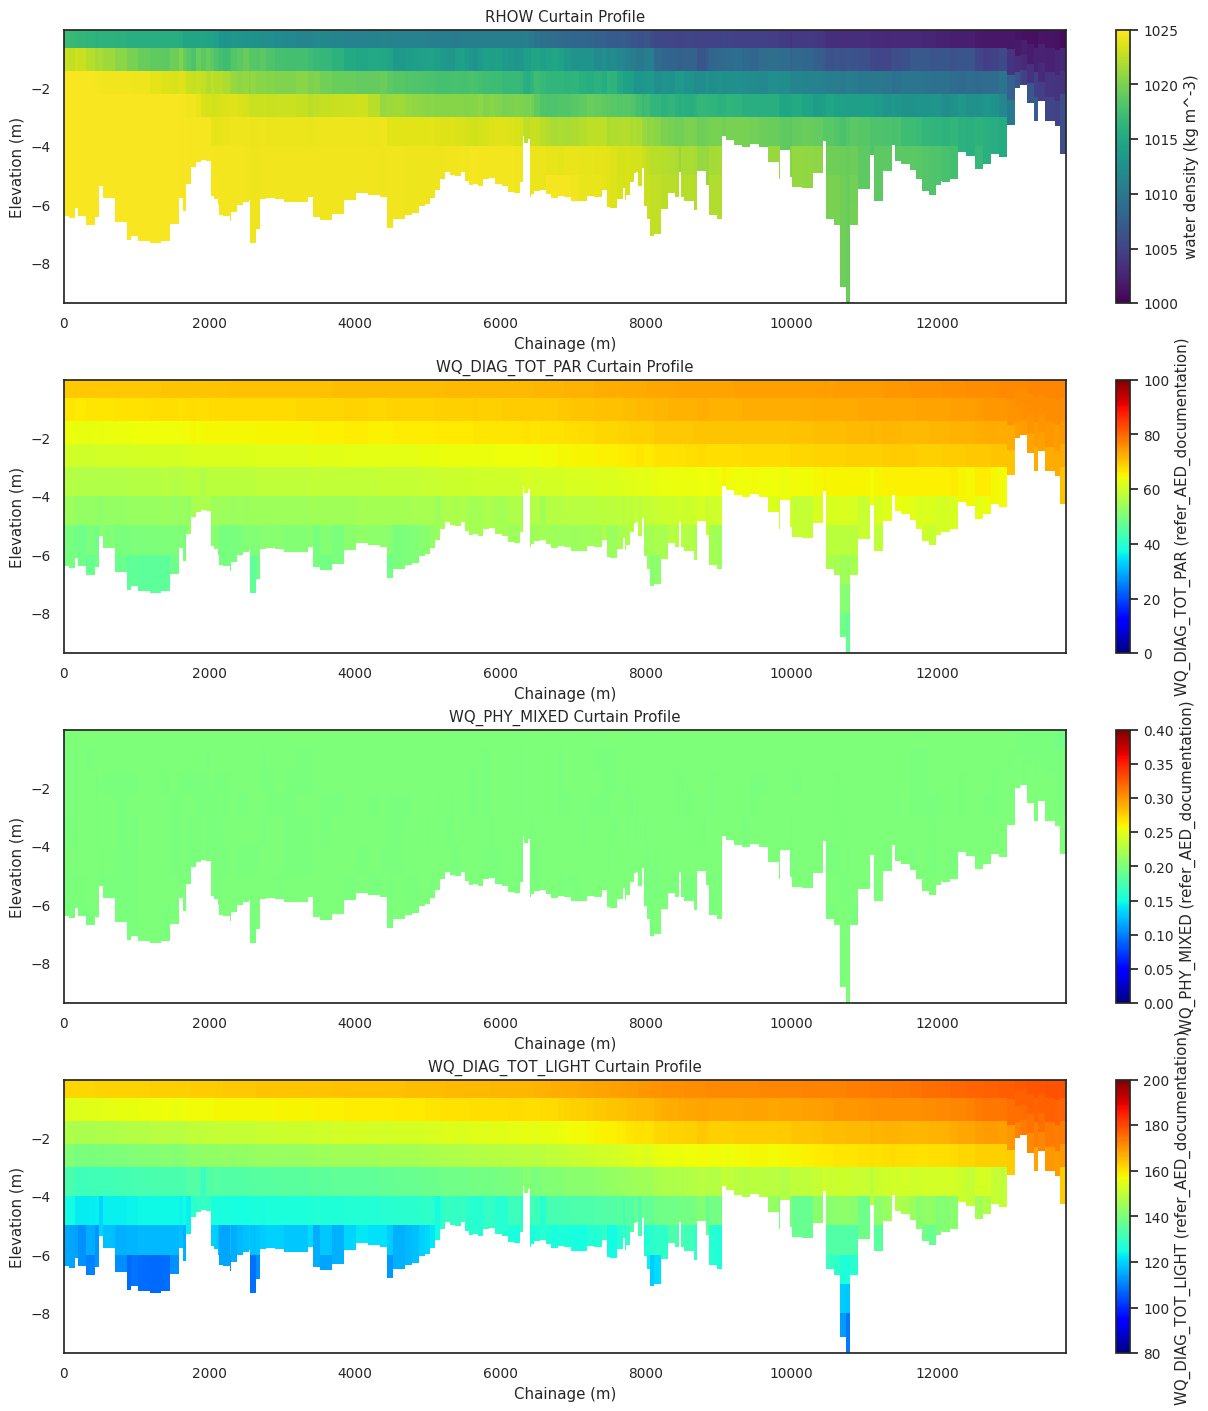

In [123]:
# Create figure
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 14), constrained_layout=True)

time = '2011-05-02 12:00'
vardict = {
    'RHOW': dict(cmap='viridis', clim=(1000, 1025)),
    'WQ_DIAG_TOT_PAR': dict(cmap='jet', clim=(0, 100)),
    'WQ_PHY_MIXED': dict(cmap='jet', clim=(0, 0.4)),
    'WQ_DIAG_TOT_LIGHT': dict(cmap='jet', clim=(80, 200)),
}

var = 'RHOW'
cspec = vardict[var]
fv.plot_curtain(polyline, var, time, ax=ax1, ec='none', **cspec)
ax1.set_title(f'{var} Curtain Profile')

var = 'WQ_DIAG_TOT_PAR'
cspec = vardict[var]
fv.plot_curtain(polyline, var, time, ax=ax2, ec='none', **cspec)
ax2.set_title(f'{var} Curtain Profile')

var = 'WQ_PHY_MIXED'
cspec = vardict[var]
fv.plot_curtain(polyline, var, time, ax=ax3, ec='none', **cspec)
ax3.set_title(f'{var} Curtain Profile')

var = 'WQ_DIAG_TOT_LIGHT'
cspec = vardict[var]
fv.plot_curtain(polyline, var, time, ax=ax4, ec='none', **cspec)
ax4.set_title(f'{var} Curtain Profile')

plt.show()

### Nutrient / chlorophyll-a / oxygen curtains

A second stack focused on biogeochemistry — total nitrogen (`WQ_DIAG_TOT_TN`), chlorophyll-a (`WQ_DIAG_PHY_TCHLA`), and dissolved oxygen (`WQ_OXY_OXY`). Useful for tracking nutrient → production → respiration pathways along the estuary.

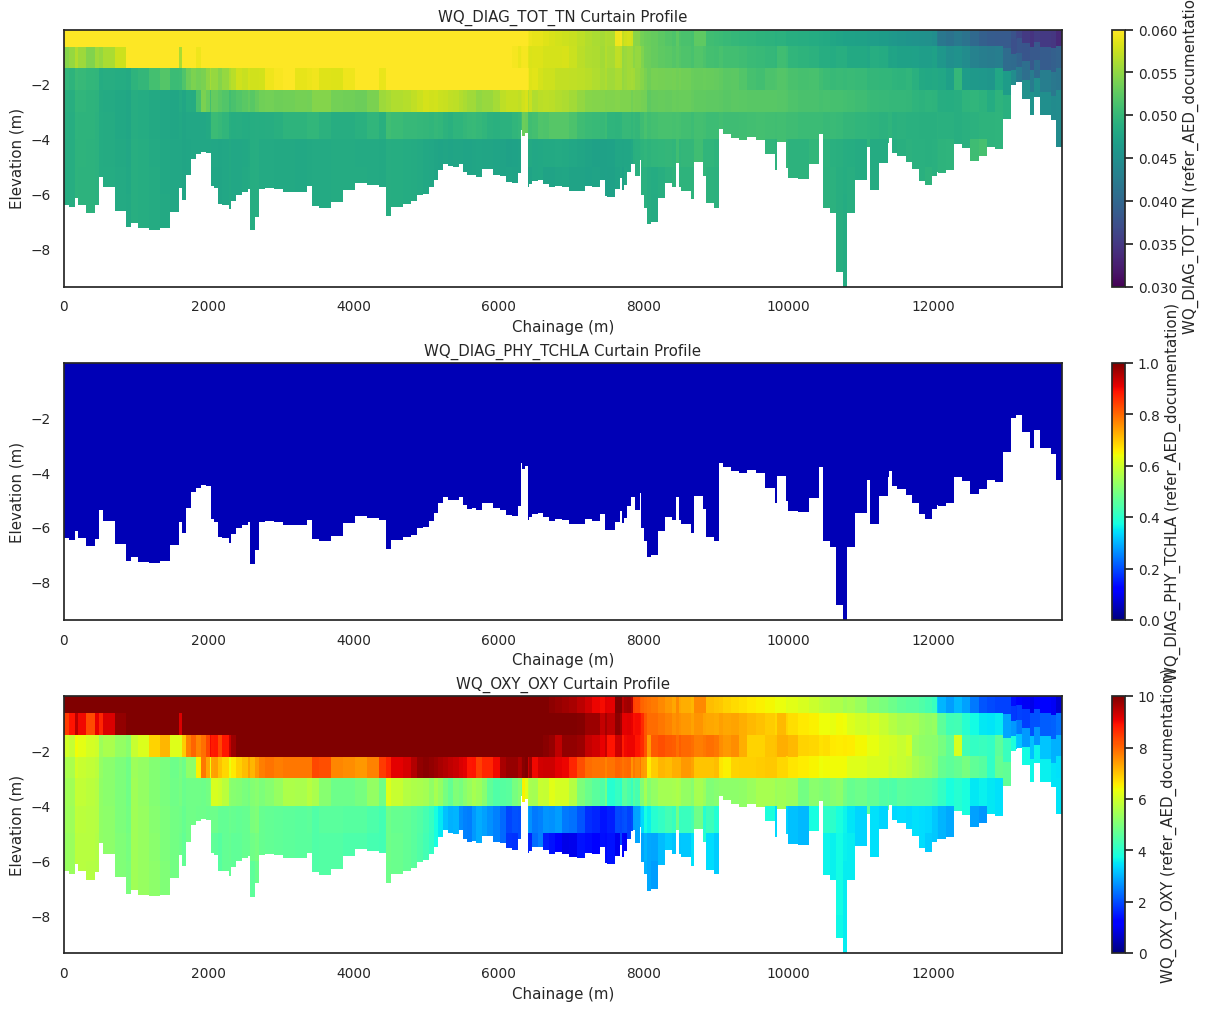

In [16]:
# Create figure
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10), constrained_layout=True)

time = '2011-05-03 12:00'
vardict = {
    'WQ_DIAG_TOT_TN': dict(cmap='viridis', clim=(0.03, 0.06)),
    'WQ_DIAG_PHY_TCHLA': dict(cmap='jet', clim=(0, 1)),
    'WQ_OXY_OXY': dict(cmap='jet', clim=(0, 10)),
}

var = 'WQ_DIAG_TOT_TN'
cspec = vardict[var]
fv.plot_curtain(polyline, var, time, ax=ax1, ec='none', **cspec)
ax1.set_title(f'{var} Curtain Profile')

var = 'WQ_DIAG_PHY_TCHLA'
cspec = vardict[var]
fv.plot_curtain(polyline, var, time, ax=ax2, ec='none', **cspec)
ax2.set_title(f'{var} Curtain Profile')

var = 'WQ_OXY_OXY'
cspec = vardict[var]
fv.plot_curtain(polyline, var, time, ax=ax3, ec='none', **cspec)
ax3.set_title(f'{var} Curtain Profile')

plt.show()

## 8. Hovmoller diagrams (depth vs. time)

A Hovmoller diagram shows how a variable evolves through the **water column** at a single station over time — the y-axis is depth and the x-axis is time. It is the best single picture for spotting settling/resuspension cycles, productivity blooms or stratification events in a WQ field.

We re-define `locs` to a single high-precision station (`P1`) before plotting a combined **TSS + Turbidity** Hovmoller on a shared time axis.

In [17]:
locs = {
    'P1': (159.08421845507237, -31.37241113710583)
}

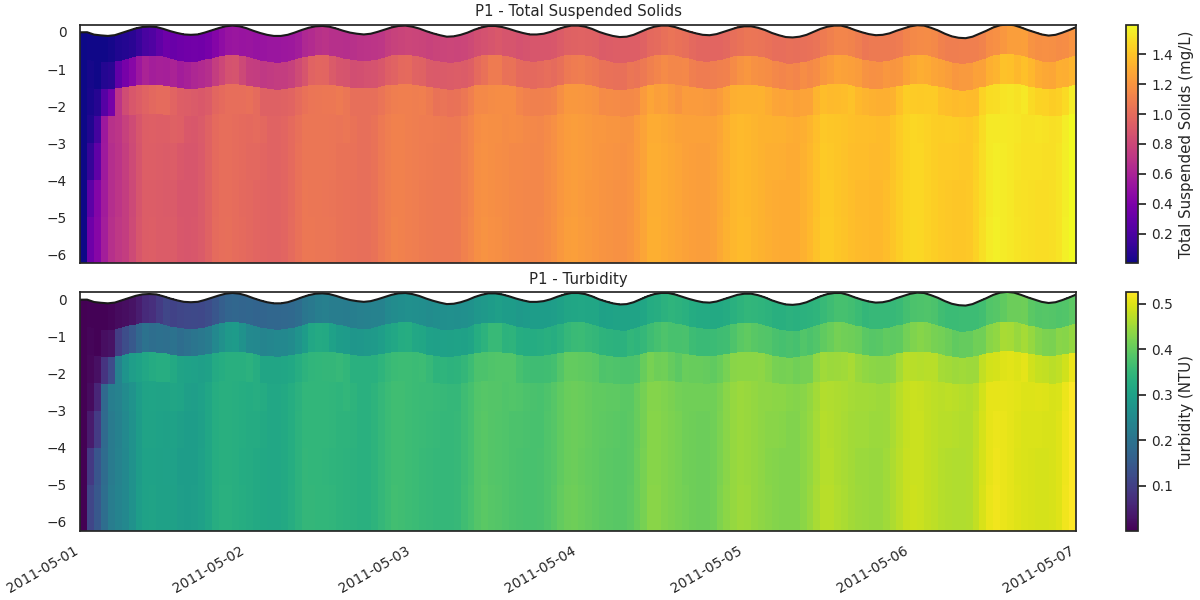

In [128]:
location = 'P1'
time_limits = slice('2011-05-01', '2011-05-07')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True, constrained_layout=True)

hov1 = fv.plot_hovmoller(locs[location], 'WQ_DIAG_TOT_TSS', ax=ax1, time_limits=time_limits, cmap='plasma')
fig.colorbar(hov1, ax=ax1, label='Total Suspended Solids (mg/L)')
ax1.set_title(f'{location} - Total Suspended Solids')

hov2 = fv.plot_hovmoller(locs[location], 'WQ_DIAG_TOT_TURBIDITY', ax=ax2, time_limits=time_limits, cmap='viridis')
fig.colorbar(hov2, ax=ax2, label='Turbidity (NTU)')
ax2.set_title(f'{location} - Turbidity')

fig.autofmt_xdate()
plt.show()

## 9. Animation export (MP4)

Drive `matplotlib.animation.FuncAnimation` by calling the `tfv` plot patch's `set_time_current(i)` each frame. Here we animate the **Turbidity** field (`WQ_DIAG_TOT_TURBIDITY`) with velocity vector overlays. The output is written to `./outputs/Turbidity_Animation.mp4`.

> **Requires** `ffmpeg` on `PATH`. If you don't have it, swap `FFMpegWriter()` for `animation.PillowWriter()` and change the suffix to `.gif`.

In [129]:
# Export an MP4 of the salinity field using matplotlib.animation.
from matplotlib import animation

output_folder = Path('/media/fileshare/AED/MATT/SpoonTest/spoon_tfvaed_example/TUFLOWFV/outputs/outputs')
output_folder.mkdir(exist_ok=True)  # Make the folder if it doesn't exist
out_file = output_folder / 'Turbidity_Animation.mp4'

time_start = '2011-05-02 00:00'
time_end = '2011-05-05 12:00'

fvx = fv.sel(Time=slice(time_start, time_end))

# Colour settings
col_spec = dict(cmap='viridis', clim=(0, 100), shading='interp', edgecolor='face')

# Vector settings
vec_spec = dict(angles='uv', scale_units='dots', scale=1/200, width=0.002,
                headwidth=2.5, headlength=4, pivot='middle', minlength=2)

variable = 'WQ_DIAG_TOT_TURBIDITY'
vector_variable = 'V'

fig, ax = plt.subplots()
ax.set_aspect('equal', adjustable='datalim')

sheet = fvx.plot(variable, 1, ax=ax, **col_spec)
vec = fvx.plot_vector(vector_variable, 1, ax=ax, **vec_spec)

def animate(i):
    sheet.set_time_current(i)
    vec.set_time_current(i)
    date = sheet.get_time_current()
    ax.set_title(date.strftime('%Y-%m-%d %H:%M'))

nframes = fvx.sizes['Time']
anim = animation.FuncAnimation(fig, animate, frames=nframes, repeat=False)
anim.save(out_file, writer=animation.FFMpegWriter(), dpi=300)
plt.close(fig)
print(f'Saved animation to {out_file}')

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Saved animation to outputs/Turbidity_Animation.mp4


## 10. Interactive views (Jupyter widgets)

Switching the backend to `%matplotlib widget` enables interactive controls. `fv.plot_interactive` adds a time slider so you can scrub through the simulation without re-rendering — here on the depth-averaged **Turbidity** field with velocity vectors. The final cell closes any leftover figures and restores the inline backend so the rest of the notebook renders normally on GitHub.

> **Note:** Interactive widgets only work in a **live** Jupyter session (with `ipympl` installed) — they will appear as static placeholders when the notebook is rendered on GitHub. Leave the cell run once so the static fallback image is visible.

GridspecLayout(children=(HBox(children=(Play(value=0, description='Play', interval=500, layout=Layout(height='…

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


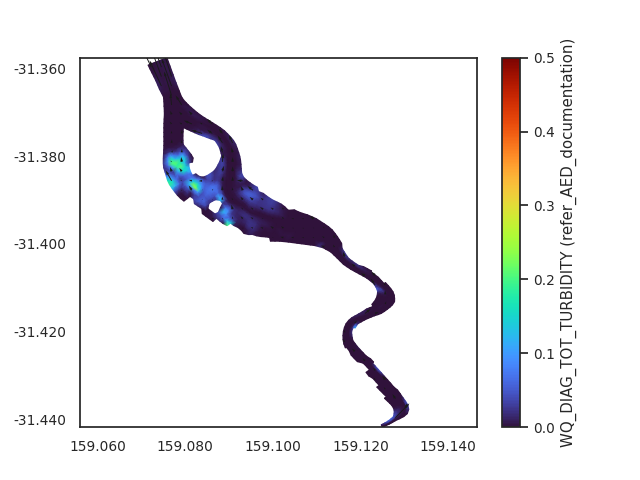

In [130]:
%matplotlib widget
fv.plot_interactive('WQ_DIAG_TOT_TURBIDITY', shading='interp', cmap='turbo', clim=(0,0.5), datum='depth', vectors=True)

In [131]:
plt.close('all')
%matplotlib inline